In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt

import sys
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

utils.load_plotting_setting()

In [4]:

# ── Sphere / calibration ──────────────────────────────────────────────────
amp2kev       = 8363.560351624732   # keV/c per amplitude unit (sphere_20260215)
sphere_radius = 50e-9               # m

# ── Sampling & window sizes (must match process_gas_data.py) ──────────────
fs                     = 5_000_000  # Hz
dt                     = 1 / fs
analysis_window_length = 2**19      # 524288 samples = 104.9 ms
search_window_length   = 2**8       # 256 samples = 51.2 µs
n_searches             = int(analysis_window_length / search_window_length) - 3  # 2045
lb                     = 2 * search_window_length   # 512 — searchable region start (matches process_gas_data.py)

T_search          = search_window_length   / fs   # 51.2 µs per sub-window
T_analysis_window = analysis_window_length / fs   # 104.9 ms per analysis window
T_searchable      = n_searches * T_search          # effective searched time per analysis window

# ── Bandpass and lowpass filter (matches process_gas_data.py) ────────────
bandpass_lb, bandpass_ub = (38000, 75000)
lowpass_order = 3

# ── Noise model (tune to match measured noise_level_amp) ─────────────────
sigma_noise_kev = 60.0  # keV/c

# ── Gas collision theory ──────────────────────────────────────────────────
mg_amu   = 131.293   # Xe
p_mbar   = 1e-6      # mbar
T_gas    = 293       # K
T_sensor = 900       # K (laser-heated sphere surface)
alpha    = 0.9       # thermal accommodation coefficient

# ── MC settings ───────────────────────────────────────────────────────────
# 128 analysis windows × 2045 sub-windows = 261,760 sub-window slots,
# matching n_noise = 2^18 = 262,144 from the previous search-window-level MC.
n_analysis_windows = 128
rng_seed           = 42

# ── Quality cut thresholds (match recon_histograms.py) ───────────────────
noise_threshold_kev = 200.0
chi2_threshold      = 700.0

# ── Output histogram bins ─────────────────────────────────────────────────
bins = np.arange(0, 2000, 25)
bc   = 0.5 * (bins[:-1] + bins[1:])
dq   = float(bins[1] - bins[0])  # keV/c

print(f'Analysis window:  {analysis_window_length} samples = {T_analysis_window*1e3:.1f} ms')
print(f'Search window:    {search_window_length} samples = {T_search*1e6:.1f} µs')
print(f'Sub-windows/win:  {n_searches}')
print(f'T_searchable:     {T_searchable*1e3:.3f} ms per analysis window')
print(f'σ_noise:          {sigma_noise_kev:.0f} keV/c')
print(f'Gas:              Xe  {p_mbar:.0e} mbar  α={alpha}  T_s={T_sensor} K')


Analysis window:  524288 samples = 104.9 ms
Search window:    256 samples = 51.2 µs
Sub-windows/win:  2045
T_searchable:     104.704 ms per analysis window
σ_noise:          60 keV/c
Gas:              Xe  1e-06 mbar  α=0.9  T_s=900 K


Total Xe rate:                   42060.444 Hz
Events per analysis window:      4410.3572
Events per search sub-window:    2.15e+00


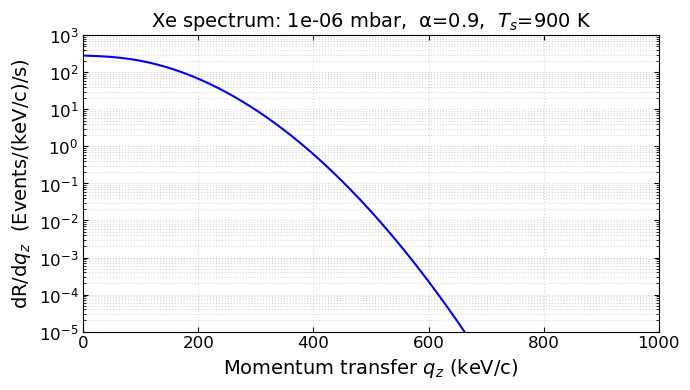

In [5]:

qq_kev = np.linspace(0.5, 2000, 2000)
drdq   = calc_gas.dgamma_dp_tot_noneq(
    qq_kev, mg_amu, p_mbar, alpha,
    T_gas=T_gas, T_sensor=T_sensor, sphere_radius=sphere_radius
)
_, drdqz = calc_gas.get_drdqz(qq_kev, drdq)
_, drdqz_smear = calc_gas.smear_drdqz_gauss(qq_kev, drdqz, sigma_noise_kev)

total_rate                 = np.trapz(drdqz, qq_kev)        # Hz
events_per_analysis_window = total_rate * T_analysis_window  # expected events per full window
events_per_search          = total_rate * T_search           # expected events per sub-window

print(f'Total Xe rate:                   {total_rate:.3f} Hz')
print(f'Events per analysis window:      {events_per_analysis_window:.4f}')
print(f'Events per search sub-window:    {events_per_search:.2e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(qq_kev, drdqz, 'b')
ax.set_ylim(1e-5, 1e3)
ax.set_xlim(0, 1000)
ax.set_xlabel('Momentum transfer $q_z$ (keV/c)')
ax.set_ylabel(r'dR/d$q_z$  (Events/(keV/c)/s)')
ax.set_title(f'Xe spectrum: {p_mbar:.0e} mbar,  α={alpha},  $T_s$={T_sensor} K')
ax.set_yscale('log')
ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()


#### First attempt: simple Poisson weighting

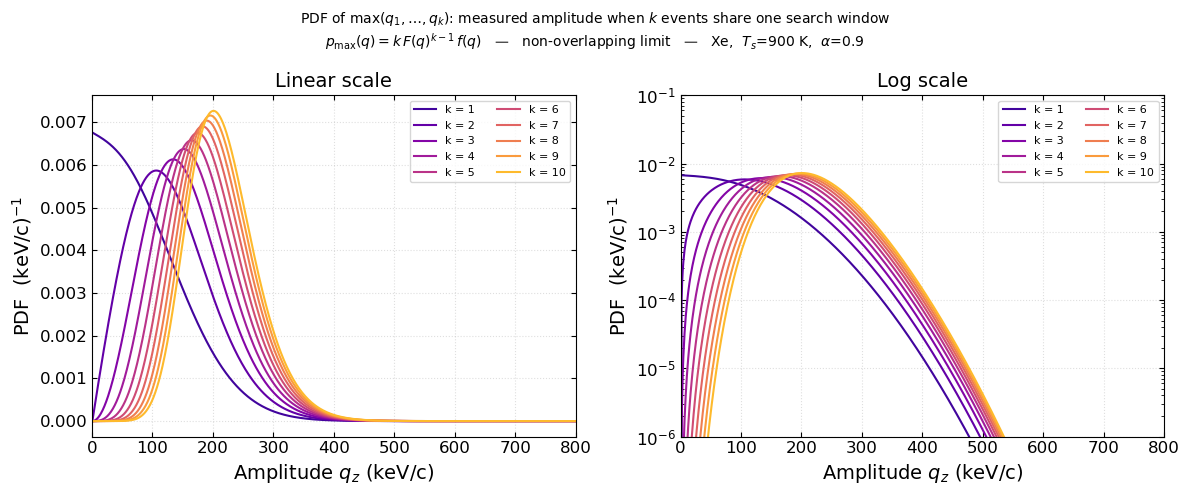

In [6]:
from scipy.integrate import cumulative_trapezoid

# ── Parameters ────────────────────────────────────────────────────────────
k_max    = 10          # plot k = 1 .. k_max
xlim_lin = (0, 800)   # keV/c, linear panel
xlim_log = (0, 800)  # keV/c, log panel
ylim_log = (1e-6, 1e-1)

# ── Normalise spectrum → single-event PDF and CDF ─────────────────────────
R_total = np.trapz(drdqz, qq_kev)
f_pdf   = drdqz / R_total
F_cdf   = cumulative_trapezoid(f_pdf, qq_kev, initial=0)
F_cdf  /= F_cdf[-1]    # ensure exactly 1 at upper end

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.colormaps['plasma'](np.linspace(0.1, 0.85, k_max))

for k, col in zip(range(1, k_max + 1), colors):
    p_max = k * F_cdf**(k - 1) * f_pdf    # order-statistic PDF
    for ax in axes:
        ax.plot(qq_kev, p_max, color=col, lw=1.5, label=f'k = {k}')

for ax in axes:
    ax.set_xlabel('Amplitude $q_z$ (keV/c)')
    ax.set_ylabel('PDF  (keV/c)$^{-1}$')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, ls=':', alpha=0.4)

axes[0].set_xlim(*xlim_lin)
axes[0].set_title('Linear scale')

axes[1].set_yscale('log')
axes[1].set_ylim(*ylim_log)
axes[1].set_xlim(*xlim_log)
axes[1].set_title('Log scale')

fig.suptitle(
    r'PDF of $\max(q_1,\ldots,q_k)$: measured amplitude when $k$ events share one search window'
    '\n'
    r'$p_{\max}(q) = k\,F(q)^{k-1}\,f(q)$   —   non-overlapping limit'
    f'   —   Xe,  $T_s$={T_sensor} K,  $\\alpha$={alpha}',
    fontsize=10,
)
plt.tight_layout()


Calculate the Poisson probabilities for mean number of events per 51 us search window.

In [120]:
from scipy.stats import poisson

# Uses total_rate and T_search from cell 3, k_max from cell 4
mu = total_rate * T_search   # expected events per search window

print(f'μ = {total_rate:.3f} Hz × {T_search*1e6:.1f} µs = {mu:.5f} events/window')
print()

header = f"{'k':>4}  {'P(k)':>10}  {'P(k) %':>10}  {'cumulative %':>14}"
print(header)
print('-' * len(header))
cumulative = 0.0
for k in range(k_max + 1):
    pk = poisson.pmf(k, mu)
    cumulative += pk
    print(f'{k:>4}  {pk:>10.6f}  {pk*100:>9.4f}%  {cumulative*100:>13.4f}%')


μ = 42060.444 Hz × 51.2 µs = 2.15349 events/window

   k        P(k)      P(k) %    cumulative %
--------------------------------------------
   0    0.116078    11.6078%        11.6078%
   1    0.249973    24.9973%        36.6051%
   2    0.269158    26.9158%        63.5208%
   3    0.193210    19.3210%        82.8418%
   4    0.104019    10.4019%        93.2437%
   5    0.044801     4.4801%        97.7238%
   6    0.016080     1.6080%        99.3318%
   7    0.004947     0.4947%        99.8265%
   8    0.001332     0.1332%        99.9596%
   9    0.000319     0.0319%        99.9915%
  10    0.000069     0.0069%        99.9984%


In [8]:
from scipy.integrate import cumulative_trapezoid
from scipy.stats import poisson

def calc_rates_per_k(qq_kev, drdqz, sigma_smear_kev, k_max=10):
    """
    Compute the expected measured rate spectrum for each pile-up multiplicity k,
    smeared with a Gaussian detector resolution.

    For exactly k events in a search window, the argmax search reports the
    largest amplitude.  In the non-overlapping limit this follows the k-th
    order statistic of the single-event distribution:

        p_max_k(q) = k * F(q)^(k-1) * f(q)

    The contribution to the measured rate spectrum from windows with exactly k
    events is:

        rate_k(q) = P(k | μ) / T_search * p_max_k(q)

    where μ = total_rate * T_search is the mean number of events per window and
    P(k | μ) is the Poisson probability.

    Parameters
    ----------
    qq_kev         : momentum axis (keV/c), uniform spacing assumed
    drdqz          : differential rate dR/dq_z (Events/(keV/c)/s) at baseline pressure
    sigma_smear_kev: Gaussian smearing width (keV/c)
    k_max          : maximum pile-up multiplicity to compute

    Returns
    -------
    rates_raw    : (k_max, len(qq_kev)) array — rate_k before smearing
    rates_smeared: (k_max, len(qq_kev)) array — rate_k after Gaussian smear
    poisson_probs: (k_max,) array — P(k | μ) for k = 1 .. k_max
    mu           : mean events per search window
    """
    R_total = np.trapz(drdqz, qq_kev)
    f_pdf   = drdqz / R_total
    F_cdf   = cumulative_trapezoid(f_pdf, qq_kev, initial=0)

    # Make sure the CDF is properly normalized
    norm    = F_cdf[-1]
    F_cdf  /= norm

    mu = R_total * T_search

    rates_raw     = np.zeros((k_max, len(qq_kev)))
    rates_smeared = np.zeros((k_max, len(qq_kev)))
    poisson_probs = np.zeros(k_max)

    for i, k in enumerate(range(1, k_max + 1)):
        pk          = poisson.pmf(k, mu)
        p_max_k     = k * F_cdf**(k - 1) * f_pdf   # order-statistic PDF (normalised to 1)

        # Normalized the rate to have the original k=1 case
        rate_k      = p_max_k * R_total           # Events/(keV/c)/s
        _, smeared  = calc_gas.smear_drdqz_gauss(qq_kev, rate_k, sigma_smear_kev)

        rates_raw[i]      = rate_k
        rates_smeared[i]  = smeared
        poisson_probs[i]  = pk

    return rates_raw, rates_smeared, poisson_probs, mu


In [ ]:
# Calculate the gas signal smeared by a Gaussian kernel
# Neglect the noise-only windows here for now
rates_raw, rates_smeared, poisson_probs, mu = calc_rates_per_k(qq_kev, drdqz, sigma_noise_kev, 20)
rates_gas_sum_smeared = poisson_probs @ rates_smeared   # Events/keV/s

#### Second attempt: pulse-shape-aware search-window MC

For each multiplicity k, simulate many single search windows directly:
- Draw k amplitudes from the spectrum and k positions uniform in [0, swl)
- Build the combined waveform using the actual calibration pulse shape LUT
- Add Gaussian noise (σ = σ_noise)
- Take max|waveform| → this is the searched amplitude

Captures: (1) noise floor from taking the max over 256 samples, (2) pulse overlap/interference between co-window events.

Pulse FWHM: 29 samples = 5.8 µs
Pulse at ±128 samples from peak: 0.0016 / 0.0571
pulse_lut shape: (256, 256)


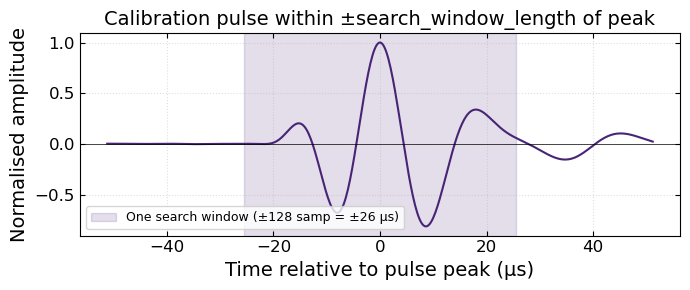

In [34]:

# ── Load calibration pulse and build search-window LUT ────────────────────
_cal     = np.load('../../data_processed/pulse_calibration/sphere_20260215_pulse_shape_template_combined.npz')
ps_raw   = _cal['ps_20v']
peak_cal = int(np.argmax(ps_raw))
ps_norm  = ps_raw / ps_raw[peak_cal]   # normalised to 1 at peak

# pulse_lut[t, p] = pulse value at sample t when peak is at position p (both in [0, swl))
# Derived from: amp[sw_start + t] += q * ps_norm[peak_cal + (t - p)]
swl       = search_window_length        # 256
_t        = np.arange(swl)
_p        = np.arange(swl)
pulse_lut = ps_norm[peak_cal + (_t[:, None] - _p[None, :])]   # (swl, swl)

print(f'Pulse FWHM: {int(np.sum(ps_norm > 0.5))} samples = {int(np.sum(ps_norm > 0.5))/fs*1e6:.1f} µs')
print(f'Pulse at ±{swl//2} samples from peak: {ps_norm[peak_cal - swl//2]:.4f} / {ps_norm[peak_cal + swl//2]:.4f}')
print(f'pulse_lut shape: {pulse_lut.shape}')

# ── Visualise pulse within ±swl samples ───────────────────────────────────
t_ext  = np.arange(-swl, swl + 1) * dt * 1e6
ps_ext = ps_norm[peak_cal - swl : peak_cal + swl + 1]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_ext, ps_ext)
ax.axvspan(-swl//2 * dt * 1e6, swl//2 * dt * 1e6,
           alpha=0.15, color='C0', label=f'One search window (±{swl//2} samp = ±{swl//2/fs*1e6:.0f} µs)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time relative to pulse peak (µs)')
ax.set_ylabel('Normalised amplitude')
ax.set_title('Calibration pulse within ±search_window_length of peak')
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()


In [43]:

def calc_searchwindow_pdfs(qq_kev, drdqz, pulse_lut, amp2kev,
                            T_search, k_max=15, n_mc=50000, rng=None):
    """
    Compute the PDF of the searched amplitude (max|waveform| in one search window)
    for exactly k signal events, using the actual pulse shape. Noise is ignored.

    For k events at random positions p_i ~ Uniform[0, swl), random signs s_i ~ ±1,
    and amplitudes q_i ~ f(q), the combined waveform is:
        W[t] = sum_i  s_i * q_i * pulse_lut[t, p_i]
    and the searched amplitude is max_t |W[t]|.

    Parameters
    ----------
    pulse_lut : (swl, swl) array  — pulse_lut[t, p] = ps_norm[peak_cal + (t - p)]
    k_max     : compute PDFs for k = 1, ..., k_max

    Returns
    -------
    amp_max_per_k : list of k_max arrays of searched amplitudes (keV/c), k=1..k_max
    """
    if rng is None:
        rng = np.random.default_rng(42)

    R_total = np.trapz(drdqz, qq_kev)
    cdf     = cumulative_trapezoid(drdqz, qq_kev, initial=0) / R_total
    swl     = pulse_lut.shape[0]
    chunk   = 2000

    amp_max_per_k = []

    for k in range(1, k_max + 1):
        q_s = np.interp(rng.uniform(0, 1, (n_mc, k)), cdf, qq_kev) / amp2kev  # amp units
        p_s = rng.integers(0, swl, (n_mc, k))
        s_s = rng.integers(0, 2, (n_mc, k)) * 2 - 1   # ±1 signs

        amp_max = np.zeros(n_mc)
        for i0 in range(0, n_mc, chunk):
            i1 = min(i0 + chunk, n_mc)
            nc = i1 - i0
            W  = np.zeros((nc, swl))
            for ki in range(k):
                W += (s_s[i0:i1, ki] * q_s[i0:i1, ki])[:, None] * pulse_lut[:, p_s[i0:i1, ki]].T
            amp_max[i0:i1] = np.max(np.abs(W), axis=1)

        amp_max_per_k.append(amp_max * amp2kev)

    return amp_max_per_k


# ── Run ───────────────────────────────────────────────────────────────────
k_max_sw = 15
n_mc_sw  = 50000

print(f'Search-window MC: k=1..{k_max_sw},  {n_mc_sw:,} realisations each…')
rng_sw = np.random.default_rng(42)
amp_max_per_k = calc_searchwindow_pdfs(
    qq_kev, drdqz, pulse_lut, amp2kev,
    T_search, k_max=k_max_sw, n_mc=n_mc_sw, rng=rng_sw,
)
print('Done.')

# ── Fine bins for per-k PDF plots (1 keV/c) ───────────────────────────────
bins_fine = np.arange(0, 2000, 1)
bc_fine   = 0.5 * (bins_fine[:-1] + bins_fine[1:])
dq_fine   = float(bins_fine[1] - bins_fine[0])

# ── Poisson-weight into rate spectrum on fine grid, then Gaussian-smear ──
mu_sw = total_rate * T_search
rates_sw_sum_fine = np.zeros(len(bc_fine))

for k in range(1, k_max_sw + 1):
    pk      = poisson.pmf(k, mu_sw)
    hh_k, _ = np.histogram(amp_max_per_k[k - 1], bins=bins_fine)
    pdf_k   = hh_k / (n_mc_sw * dq_fine)
    rates_sw_sum_fine += pk * pdf_k / T_search

_, rates_sw_smear = calc_gas.smear_drdqz_gauss(bc_fine, rates_sw_sum_fine, sigma_noise_kev)

# ── Coarse version for step plots ────────────────────────────────────────
rates_sw_sum = np.zeros(len(bc))
for k in range(1, k_max_sw + 1):
    pk      = poisson.pmf(k, mu_sw)
    hh_k, _ = np.histogram(amp_max_per_k[k - 1], bins=bins)
    pdf_k   = hh_k / (n_mc_sw * dq)
    rates_sw_sum += pk * pdf_k / T_search

print(f'μ = {mu_sw:.4f} events/window')
print(f'Integral of rates_sw_smear × dq = {np.trapz(rates_sw_smear, bc_fine):.2f} Hz')


Search-window MC: k=1..15,  50,000 realisations each…
Done.
μ = 2.1535 events/window
Integral of rates_sw_smear × dq = 17312.86 Hz


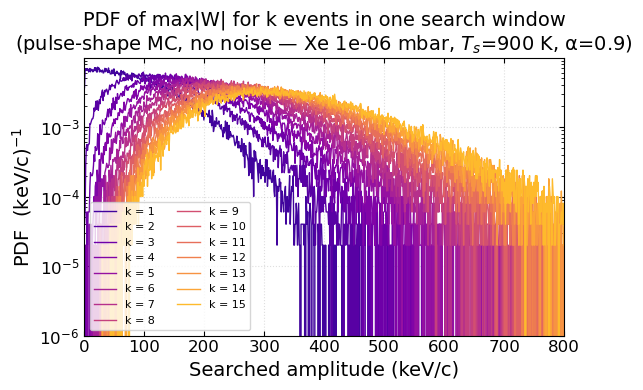

In [41]:

# ── PDF of searched amplitude for each k (1 keV/c bins) ──────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = plt.colormaps['plasma'](np.linspace(0.1, 0.85, k_max_sw))

for k, col in enumerate(colors, start=1):
    hh_k, _ = np.histogram(amp_max_per_k[k - 1], bins=bins_fine)
    pdf_k   = hh_k / (n_mc_sw * dq_fine)
    ax.plot(bc_fine, pdf_k, color=col, lw=1.0, label=f'k = {k}')

ax.set_yscale('log')
ax.set_xlim(0, 800)
ax.set_ylim(1e-6, None)
ax.set_xlabel('Searched amplitude (keV/c)')
ax.set_ylabel('PDF  (keV/c)$^{-1}$')
ax.set_title(
    f'PDF of max|W| for k events in one search window\n'
    f'(pulse-shape MC, no noise — Xe {p_mbar:.0e} mbar, $T_s$={T_sensor} K, α={alpha})'
)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()


#### Below is most likely incorrect

#### Third attempt: semi-analyitical modeling using convolution

In [ ]:

# ── Analytical convolution model for pileup ───────────────────────────────
#
# Cross-coupling coefficient between two events at separation Δ in the window:
#   c(Δ) = ps_norm[peak_cal + Δ]
#
# At the position of the maximum event, the other k-1 events contribute
# cross-coupling noise with variance:
#   Var[ε] = (k-1) * <q²> * C²
# where C² = (1/swl) * Σ_Δ c(Δ)² = ||ps_norm||² / swl
#
# So PDF_k ≈ [order-stat PDF for k] ⊛ G(0, σ_k)
# Combined with detector resolution:
#   σ_total_k = sqrt(σ_noise² + (k-1) * <q²> * C²)

R_total_an = np.trapz(drdqz, qq_kev)
f_pdf_an   = drdqz / R_total_an
F_cdf_an   = cumulative_trapezoid(f_pdf_an, qq_kev, initial=0)
F_cdf_an  /= F_cdf_an[-1]

# Mean squared coupling from pulse shape
C_sq   = np.sum(ps_norm**2) / swl
q2_mean = np.trapz(qq_kev**2 * f_pdf_an, qq_kev)   # <q²> in (keV/c)²

print(f'C²  = {C_sq:.4f}  (mean squared cross-coupling per sample)')
print(f'⟨q²⟩ = {q2_mean:.1f}  (keV/c)²   →  q_rms = {np.sqrt(q2_mean):.1f} keV/c')
print()

k_max_an = 20
rates_conv_smeared = np.zeros((k_max_an, len(qq_kev)))
poisson_probs_an   = np.zeros(k_max_an)
mu_an              = R_total_an * T_search

print(f"{'k':>3}  {'σ_cross':>10}  {'σ_total':>10}  {'P(k)':>10}")
print('-' * 40)

for i, k in enumerate(range(1, k_max_an + 1)):
    pk             = poisson.pmf(k, mu_an)
    sigma_cross    = np.sqrt(max(k - 1, 0) * q2_mean * C_sq)
    sigma_total    = np.sqrt(sigma_noise_kev**2 + sigma_cross**2)
    p_max_k        = k * F_cdf_an**(k - 1) * f_pdf_an   # order-stat PDF
    rate_k         = p_max_k * R_total_an
    
    _, smeared     = calc_gas.smear_drdqz_gauss(qq_kev, rate_k, sigma_total)
    rates_conv_smeared[i] = smeared
    poisson_probs_an[i]   = pk
    print(f'{k:>3}  {sigma_cross:>10.1f}  {sigma_total:>10.1f}  {pk:>10.6f}')

rates_conv_sum = poisson_probs_an @ rates_conv_smeared


C²  = 0.1995  (mean squared cross-coupling per sample)
⟨q²⟩ = 13550.2  (keV/c)²   →  q_rms = 116.4 keV/c

  k     σ_cross     σ_total        P(k)
----------------------------------------
  1         0.0        60.0    0.249973
  2        52.0        79.4    0.269158
  3        73.5        94.9    0.193210
  4        90.0       108.2    0.104019
  5       104.0       120.0    0.044801
  6       116.3       130.8    0.016080
  7       127.3       140.8    0.004947
  8       137.6       150.1    0.001332
  9       147.0       158.8    0.000319
 10       156.0       167.1    0.000069
 11       164.4       175.0    0.000013
 12       172.4       182.6    0.000002
 13       180.1       189.8    0.000000
 14       187.5       196.8    0.000000
 15       194.5       203.6    0.000000
 16       201.4       210.1    0.000000
 17       208.0       216.4    0.000000
 18       214.4       222.6    0.000000
 19       220.6       228.6    0.000000
 20       226.6       234.4    0.000000


In [51]:

# ── Amplitude-dependent smearing applied to the original signal ───────────
#
# For a true event at amplitude q, the cross-coupling noise from the μ co-events
# that are all smaller than q has variance:
#
#   σ_cross²(q) = μ · C² · ∫₀^q q'² f(q') dq'
#
# (since F(q) · <q'²|q'<q> = ∫₀^q q'² f(q') dq' — the F(q) factors cancel)
#
# Combined with detector resolution:
#   σ_eff²(q) = σ_noise² + μ · C² · ∫₀^q q'² f(q') dq'
#
# The smeared spectrum:
#   R_meas(a) = ∫ drdqz(q) · G(a − q; σ_eff(q)) dq

# Cumulative second moment: ∫₀^q q'² f(q') dq'
q2_cumul  = cumulative_trapezoid(qq_kev**2 * f_pdf_an, qq_kev, initial=0)  # (keV/c)²

sigma_eff_sq  = sigma_noise_kev**2 + mu_an * C_sq * q2_cumul
sigma_eff_amp = np.sqrt(sigma_eff_sq)   # shape (N,) — one σ per source amplitude

print(f'σ_eff at q=100 keV/c: {np.interp(100, qq_kev, sigma_eff_amp):.1f} keV/c')
print(f'σ_eff at q=300 keV/c: {np.interp(300, qq_kev, sigma_eff_amp):.1f} keV/c')
print(f'σ_eff at q=600 keV/c: {np.interp(600, qq_kev, sigma_eff_amp):.1f} keV/c')

# Smear: R_meas[j] = Σ_i drdqz[i] · G(a_j − q_i; σ_eff[i]) · dq
dq_an   = float(qq_kev[1] - qq_kev[0])
diffs   = qq_kev[:, None] - qq_kev[None, :]          # (N_out, N_src)
sig_mat = sigma_eff_amp[None, :]                      # (1, N_src)
gauss_mat = np.exp(-0.5 * (diffs / sig_mat)**2) / (np.sqrt(2 * np.pi) * sig_mat)
rates_amp_dep_smear = gauss_mat @ drdqz * dq_an       # (N_out,)  Events/(keV/c)/s


σ_eff at q=100 keV/c: 66.3 keV/c
σ_eff at q=300 keV/c: 94.9 keV/c
σ_eff at q=600 keV/c: 97.1 keV/c


k-fold PDFs computed.
Integral rates_kfold_smear × dq = 17261.1 Hz


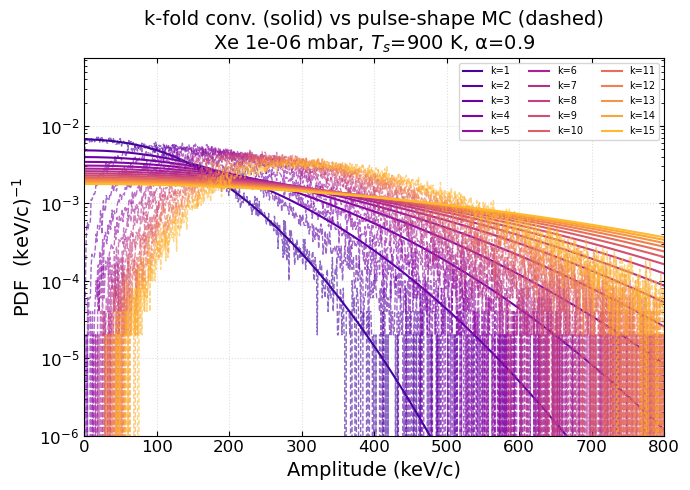

In [55]:

# ── PDF estimation by k-fold convolution of amplitude distribution ────────
#
# Each gas collision imparts momentum in a random ±z direction, so each
# event's sign is independent and uniform ±1.  For k such events:
#
#   Searched amp ~ |Σᵢ sᵢ qᵢ|  where sᵢ ~ ±1, qᵢ ~ f(q)
#
# The PDF of Σᵢ sᵢ qᵢ is the k-fold convolution of the symmetric
# distribution g(a) = ½ f(|a|).  Taking the absolute value:
#
#   pdf_k(a) = 2 · g^(*k)(a)   for a ≥ 0

def calc_kfold_pdfs(qq_kev, drdqz, k_max=15):
    """
    Estimate per-k searched-amplitude PDFs via k-fold convolution of g(a)=½f(|a|).

    Returns
    -------
    pdfs : list of k_max arrays on qq_kev grid, each normalised to ∫pdf da = 1
    """
    dq      = float(qq_kev[1] - qq_kev[0])
    n       = len(qq_kev)
    R_total = np.trapz(drdqz, qq_kev)
    f_pdf   = drdqz / R_total  # normalised single-event PDF

    # FFT grid large enough so k_max-fold conv does not wrap around
    n_pad = 2 ** int(np.ceil(np.log2(n * k_max * 2 + 512)))

    # Build symmetric g: g_arr[i]=g(i·dq), g_arr[n_pad-i]=g(-i·dq)
    g_arr = np.zeros(n_pad)
    g_arr[:n]         = 0.5 * f_pdf
    g_arr[n_pad-n+1:] = 0.5 * f_pdf[-1:0:-1]   # negative half (mirrored)
    g_hat = np.fft.rfft(g_arr * dq, n=n_pad)

    qq_pos = np.arange(n_pad // 2) * dq   # positive output grid

    pdfs    = []
    g_hat_k = g_hat.copy()

    for k in range(1, k_max + 1):
        if k > 1:
            g_hat_k = g_hat_k * g_hat

        # 2 × positive half of g^(*k) gives PDF of |Σᵢ sᵢ qᵢ|
        gk_pos = np.maximum(np.fft.irfft(g_hat_k, n=n_pad)[:n_pad//2] / dq, 0)
        pdf_k  = 2 * np.interp(qq_kev, qq_pos, gk_pos, left=0, right=0)
        pdfs.append(pdf_k)

    return pdfs


# ── Run ───────────────────────────────────────────────────────────────────
k_max_kf = k_max_sw
pdfs_kf = calc_kfold_pdfs(qq_kev, drdqz, k_max=k_max_kf)
print('k-fold PDFs computed.')

# ── Poisson-weight → rate spectrum → Gaussian smear ──────────────────────
mu_kf = total_rate * T_search
rates_kfold_sum = np.zeros(len(qq_kev))
for k in range(1, k_max_kf + 1):
    pk = poisson.pmf(k, mu_kf)
    rates_kfold_sum += pk * pdfs_kf[k - 1] / T_search

_, rates_kfold_smear = calc_gas.smear_drdqz_gauss(qq_kev, rates_kfold_sum, sigma_noise_kev)
print(f'Integral rates_kfold_smear × dq = {np.trapz(rates_kfold_smear, qq_kev):.1f} Hz')

# ── Per-k PDF comparison: k-fold conv vs pulse-shape MC ──────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.colormaps['plasma'](np.linspace(0.1, 0.85, k_max_kf))

for k, col in enumerate(colors, start=1):
    hh_k, _ = np.histogram(amp_max_per_k[k - 1], bins=bins_fine)
    pdf_mc   = hh_k / (n_mc_sw * dq_fine)
    ax.plot(bc_fine, pdf_mc,         color=col, lw=1.0, ls='--', alpha=0.6)
    ax.plot(qq_kev,  pdfs_kf[k - 1], color=col, lw=1.5, label=f'k={k}')

ax.set_yscale('log')
ax.set_xlim(0, 800)
ax.set_ylim(1e-6, None)
ax.set_xlabel('Amplitude (keV/c)')
ax.set_ylabel('PDF  (keV/c)$^{-1}$')
ax.set_title(
    f'k-fold conv. (solid) vs pulse-shape MC (dashed)\n'
    f'Xe {p_mbar:.0e} mbar, $T_s$={T_sensor} K, α={alpha}'
)
ax.legend(fontsize=7, ncol=3)
ax.grid(True, ls=':', alpha=0.4)
plt.tight_layout()


Matching MC pressure: 1e-06 mbar


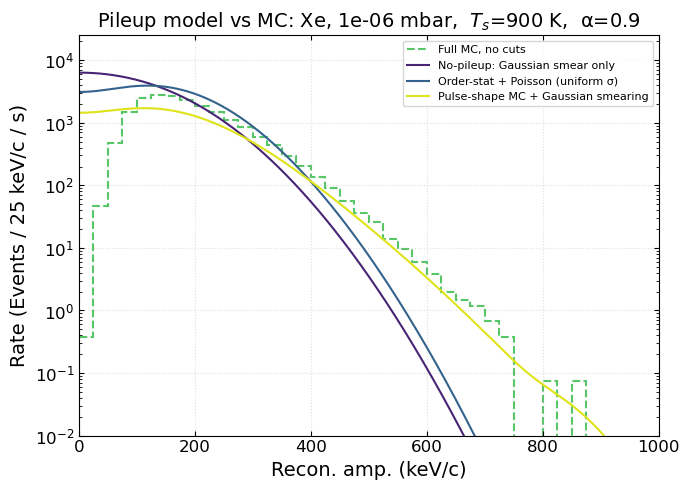

In [73]:
bw_kev = 25 # Bin width in keV/c

# ── Load MC results ───────────────────────────────────────────────────────
_mc = np.load('../../data_processed/mc_sims/mc_search_effects.npz')
mc_bc           = _mc['bc']
mc_p_mbar_list  = _mc['p_mbar_baseline'] * _mc['p_multipliers']
mc_rate_nocut   = _mc['rate_nocut']

mc_p_idx   = np.argmin(np.abs(mc_p_mbar_list - p_mbar))
mc_rate_nc = mc_rate_nocut[mc_p_idx]
print(f'Matching MC pressure: {mc_p_mbar_list[mc_p_idx]:.0e} mbar')

# ── Spectra ───────────────────────────────────────────────────────────────
spec_original    = bw_kev * drdqz_smear
spec_pileup      = bw_kev * rates_gas_sum_smeared
spec_sw_smear    = bw_kev * rates_sw_smear
spec_conv        = bw_kev * rates_conv_sum
spec_amp_dep     = bw_kev * rates_amp_dep_smear
spec_kfold       = bw_kev * rates_kfold_smear

fig, ax = plt.subplots(figsize=(7, 5))

ax.stairs(mc_rate_nc, bins, color='C3', lw=1.5, ls='--', label='Full MC, no cuts')
ax.plot(qq_kev,  spec_original,   'C0', lw=1.5, label='No-pileup: Gaussian smear only')
ax.plot(qq_kev,  spec_pileup,     'C1', lw=1.5, label='Order-stat + Poisson (uniform σ)')
ax.plot(bc_fine, spec_sw_smear,   'C4', lw=1.5, label='Pulse-shape MC + Gaussian smearing')
# ax.plot(qq_kev,  spec_conv,       'C2', lw=1.5, label='Analytical conv. (order-stat ⊛ G(σ_k))')
# ax.plot(qq_kev,  spec_amp_dep,    'C5', lw=1.5, label='Amp-dep smear on original signal')
# ax.plot(qq_kev,  spec_kfold,      'C6', lw=1.5, label='k-fold amp. conv. (random ±1 signs)')

ax.set_yscale('log')
ax.set_ylim(1e-2, 2.5e4)
ax.set_xlim(0, 1000)
ax.set_xlabel('Recon. amp. (keV/c)')
ax.set_ylabel('Rate (Events / 25 keV/c / s)')
ax.legend(fontsize=8)
ax.grid(True, ls=':', alpha=0.4)
ax.set_title(
    f'Pileup model vs MC: Xe, {p_mbar:.0e} mbar,  '
    r'$T_s$=' + f'{T_sensor} K,  α={alpha}'
)
plt.tight_layout()
